# Baseline screening — MLP & XGBoost on M2OR (molecule ‖ protein)

Runs the MP baselines across **splits** and **protein variants**, with on-disk
caching (`notebooks/cache/results.json`) so results survive kernel restarts and
already-computed configs are never recomputed.

The curated comparison table also reads `results/tables/attention_results.csv`.
That file is updated after every completed attention setup, so re-running the table
cell while `train_attention.py` is active shows all results available so far.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
warnings.filterwarnings('ignore')

# locate repo root (has pyproject.toml) regardless of where the kernel started
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from orbind import dataset as D
from orbind.baselines import run_one

DATA = ROOT / 'data'
CACHE = ROOT / 'notebooks' / 'cache'; CACHE.mkdir(parents=True, exist_ok=True)
print('repo root:', ROOT)

repo root: c:\Users\User\Desktop\SberWork\orbind


In [2]:
# --- load data + embeddings -------------------------------------------------
PAIRS = pd.read_csv(DATA / 'processed' / 'pairs_curated.csv')
ESM   = D.load_npz_dict(DATA / 'embeddings' / 'proteins' / 'esm2_650m_mean_curated.npz')
GIN   = D.load_npz_dict(DATA / 'embeddings' / 'molecules' / 'gin_supervised_contextpred.npz')
print(f'pairs={len(PAIRS)} | proteins={len(ESM)} | molecules={len(GIN)}')

# PROT_VARIANTS: tag -> (prot_dict, random_prot, mol_dict_override)
# mol_dict_override=None means use GIN (default).
PROT_VARIANTS = {
    'ESM': (ESM, False, None),
}

pairs=21384 | proteins=409 | molecules=488


In [3]:
# --- one-hot baselines ----------------------------------------
_prot_seqs = sorted(PAIRS["receptor"].unique())
_mol_inks  = sorted(PAIRS["inchikey"].unique())

def _build_onehot(keys):
    idx = {k: i for i, k in enumerate(keys)}
    n   = len(keys)
    out = {}
    for k in keys:
        v = np.zeros(n, dtype=np.float32); v[idx[k]] = 1.0
        out[k] = v
    return out

ONEHOT_PROT = _build_onehot(_prot_seqs)
ONEHOT_MOL  = _build_onehot(_mol_inks)

PROT_VARIANTS['onehot_prot'] = (ONEHOT_PROT, False, None)
PROT_VARIANTS['onehot_mol']  = (ESM,         False, ONEHOT_MOL)
PROT_VARIANTS['onehot_both'] = (ONEHOT_PROT, False, ONEHOT_MOL)
print(f'variants: {list(PROT_VARIANTS)}')

variants: ['ESM', 'onehot_prot', 'onehot_mol', 'onehot_both']


In [4]:
# --- full M2OR dataset (780 receptors) --------------------------------------
import importlib; importlib.reload(D)

_emb_full   = DATA / 'embeddings' / 'proteins' / 'esm2_650m_mean_full.npz'
_pairs_full = DATA / 'processed'  / 'pairs_m2or_full.csv'

if _emb_full.exists():
    PAIRS_FULL = pd.read_csv(_pairs_full)
    ESM_FULL   = D.load_npz_dict(_emb_full)

    _prot_seqs_full = sorted(PAIRS_FULL["receptor"].unique())
    _mol_inks_full  = sorted(PAIRS_FULL["inchikey"].unique())
    ONEHOT_PROT_FULL = _build_onehot(_prot_seqs_full)
    ONEHOT_MOL_FULL  = _build_onehot(_mol_inks_full)

    PROT_VARIANTS_FULL = {
        'ESM':         (ESM_FULL,          False, None),
        'onehot_prot': (ONEHOT_PROT_FULL,  False, None),
        'onehot_mol':  (ESM_FULL,          False, ONEHOT_MOL_FULL),
        'onehot_both': (ONEHOT_PROT_FULL,  False, ONEHOT_MOL_FULL),
    }
    print(f'full: {len(PAIRS_FULL)} pairs | {len(ESM_FULL)} proteins | '
          f'ONEHOT dims: prot={len(_prot_seqs_full)}, mol={len(_mol_inks_full)}')
else:
    PAIRS_FULL = None
    PROT_VARIANTS_FULL = {}
    print(f'⚠ {_emb_full.name} not found — re-run 05_per_residue_embeddings.py first')

full: 30745 pairs | 780 proteins | ONEHOT dims: prot=780, mol=494


In [5]:
# --- on-disk result cache ---------------------------------------------------
CACHE_FILE = CACHE / 'results.json'

def _load(): return json.loads(CACHE_FILE.read_text()) if CACHE_FILE.exists() else {}
def _save(c): CACHE_FILE.write_text(json.dumps(c, indent=2))

def cached_run(tag, prot, random_prot, head, split,
               seed=42, force=False, mol=None, pairs=None, dataset='curated'):
    cache = _load()
    # backward-compat: curated keys have no prefix (existing cache reused)
    key = f'{tag}|{head}|{split}|seed{seed}' if dataset == 'curated' \
          else f'{dataset}|{tag}|{head}|{split}|seed{seed}'
    if key in cache and not force:
        return {**cache[key], 'dataset': dataset}
    _pairs = pairs if pairs is not None else PAIRS
    _mol   = mol   if mol   is not None else GIN
    m, info = run_one(_pairs, prot, _mol, head, split,
                      random_prot=random_prot, seed=seed)
    rec = {'dataset': dataset, 'tag': tag, 'head': head, 'split': split, 'seed': seed,
           **{k: round(float(v), 4) for k, v in m.items()}, **info}
    cache[key] = rec; _save(cache)
    return rec

In [6]:
# --- run the grid (cached, auto-skips already-computed) ---------------------
HEADS  = ['boost']
SPLITS = ['stratified', 'group_molecule', 'group_receptor']

rows = []

# curated (409 receptors)
for tag, (prot, rnd, mol_override) in PROT_VARIANTS.items():
    for head in HEADS:
        for split in SPLITS:
            rows.append(cached_run(tag, prot, rnd, head, split,
                                   mol=mol_override, dataset='curated'))

# full (780 receptors) — skipped silently if ESM_FULL not ready
for tag, (prot, rnd, mol_override) in PROT_VARIANTS_FULL.items():
    for head in HEADS:
        for split in SPLITS:
            rows.append(cached_run(tag, prot, rnd, head, split,
                                   mol=mol_override, pairs=PAIRS_FULL, dataset='full'))

res = pd.DataFrame(rows)
n_cur = (res['dataset'] == 'curated').sum()
n_ful = (res['dataset'] == 'full').sum()
print(f"loaded {len(res)} results  (curated={n_cur}, full={n_ful})")


loaded 24 results  (curated=12, full=12)


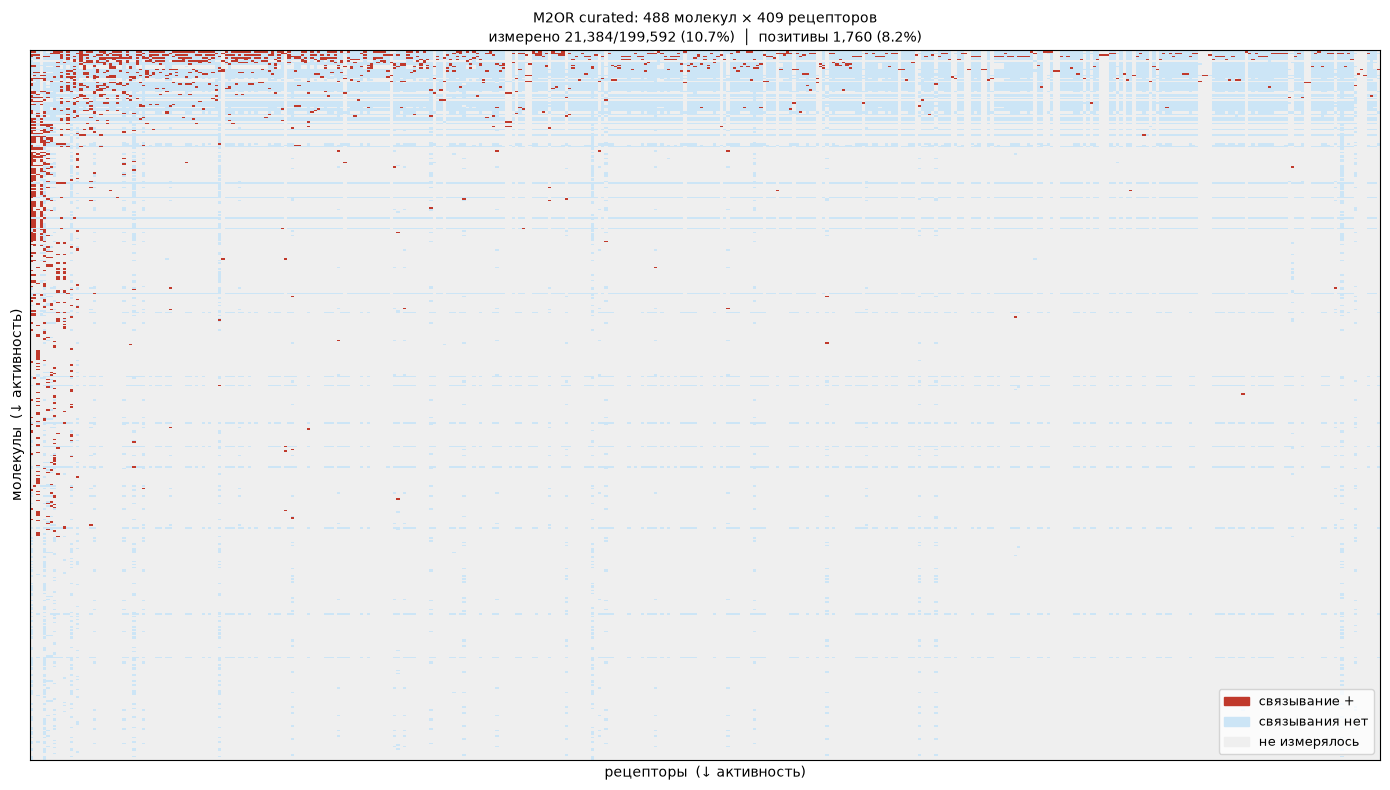

In [7]:
# --- Матрица связывания датасета (без предсказаний) -------------------------
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

_FIG = ROOT / "notebooks" / "figures"; _FIG.mkdir(exist_ok=True)

mols_u = sorted(PAIRS["inchikey"].unique())
recs_u = sorted(PAIRS["receptor"].unique())
mol_ix = {m: i for i, m in enumerate(mols_u)}
rec_ix = {r: i for i, r in enumerate(recs_u)}

M_raw = np.full((len(mols_u), len(recs_u)), np.nan)
M_raw[PAIRS["inchikey"].map(mol_ix).values,
      PAIRS["receptor"].map(rec_ix).values] = PAIRS["label"].values.astype(float)

mol_act = PAIRS[PAIRS["label"] == 1].groupby("inchikey").size()
rec_act = PAIRS[PAIRS["label"] == 1].groupby("receptor").size()
mols_s  = sorted(mols_u, key=lambda m: -mol_act.get(m, 0))
recs_s  = sorted(recs_u, key=lambda r: -rec_act.get(r, 0))
M_s = M_raw[np.ix_([mol_ix[m] for m in mols_s], [rec_ix[r] for r in recs_s])]

cmap_raw = ListedColormap(['#cce5f6', '#c0392b'])
cmap_raw.set_bad('#efefef')

n_pos  = int(PAIRS["label"].sum())
n_meas = len(PAIRS)
n_tot  = len(mols_u) * len(recs_u)

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(M_s, cmap=cmap_raw, vmin=0, vmax=1, aspect='auto', interpolation='nearest')
ax.set_title(
    f"M2OR curated: {len(mols_u)} молекул × {len(recs_u)} рецепторов\n"
    f"измерено {n_meas:,}/{n_tot:,} ({100*n_meas/n_tot:.1f}%)  │  "
    f"позитивы {n_pos:,} ({100*PAIRS['label'].mean():.1f}%)",
    fontsize=10
)
ax.set_xlabel("рецепторы  (↓ активность)")
ax.set_ylabel("молекулы  (↓ активность)")
ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
ax.legend(handles=[
    Patch(color='#c0392b', label='связывание +'),
    Patch(color='#cce5f6', label='связывания нет'),
    Patch(color='#efefef', label='не измерялось'),
], loc='lower right', fontsize=9)
fig.tight_layout()
fig.savefig(_FIG / "raw_binding_matrix.png", dpi=140, bbox_inches='tight')
plt.show()

In [8]:
# ── Unified results ────────────────────────────────────────────────────────
# Two tables with the same layout:
#   Rows:    metric (outer) × split (inner)
#   Columns: method

import torch
from orbind.dataset import metrics as _dm

METRICS_ALL  = ['AUROC', 'AUPRC', 'MCC', 'F1']
SPLITS_ORDER = ['stratified', 'group_molecule', 'group_receptor']
TAG_RENAME   = {'ESM': 'ESM+GIN'}

ATTN_METHODS = ['Attn·flat-cross', 'Attn·flat-self',
                'Attn·site-cross', 'Attn·site-self']
METHODS_CURATED = ['mol_freq', 'prot_freq', 'prod',
                   'onehot_prot', 'onehot_mol', 'onehot_both',
                   'ESM+GIN', 'GNN·signed', *ATTN_METHODS]
METHODS_FULL    = ['mol_freq', 'prot_freq', 'prod',
                   'onehot_prot', 'onehot_mol', 'onehot_both', 'ESM+GIN']

# ── 1. Bayes marginals ─────────────────────────────────────────────────────
def _marginals(pairs, prot_keys, mol_keys, split, seed=42):
    mask = pairs["receptor"].isin(prot_keys) & pairs["inchikey"].isin(mol_keys)
    p  = pairs[mask].reset_index(drop=True)
    y  = p["label"].to_numpy(dtype=np.float32)
    tr, te = D.split(p, y, kind=split, test_size=0.2, seed=seed)
    p_tr, p_te, y_te = p.iloc[tr], p.iloc[te], y[te]
    pr = float(y[tr].mean())
    mf = p_tr.groupby("inchikey")["label"].mean().to_dict()
    rf = p_tr.groupby("receptor")["label"].mean().to_dict()
    s_mol  = p_te["inchikey"].map(mf).fillna(pr).values
    s_rec  = p_te["receptor"].map(rf).fillna(pr).values
    s_prod = s_mol * s_rec / (pr + 1e-9)
    return {'mol_freq':  _dm(y_te, s_mol),
            'prot_freq': _dm(y_te, s_rec),
            'prod':      _dm(y_te, s_prod)}

# ── 2. GNN signed · boost ──────────────────────────────────────────────────
GNN_REGIME_MAP = {'transductive': 'stratified', 'inductive_molecule': 'group_molecule'}
gnn_rows = []
for path in sorted((ROOT / 'results' / 'checkpoints').glob('gnn_signed_unentangled_boost_*.pt')):
    ckpt = torch.load(path, map_location='cpu', weights_only=False)
    split_name = GNN_REGIME_MAP.get(ckpt.get('regime', ''))
    if split_name is None:
        continue
    _, y_te = ckpt['test_sup']
    m = _dm(y_te.numpy(), ckpt['test_scores'])
    gnn_rows.append({'method': 'GNN·signed', 'split': split_name,
                     **{k: round(v, 3) for k, v in m.items()}})
if not gnn_rows:
    print('GNN checkpoints not found — train first (train_gnn_link.py --mp_mode signed)')

# ── 3. Helpers ─────────────────────────────────────────────────────────────
def _make_long(dataset):
    long = []
    def add(method, split, md):
        for metric, val in md.items():
            if metric in METRICS_ALL:
                long.append({'method': TAG_RENAME.get(method, method), 'split': split,
                             'metric': metric, 'value': round(float(val), 3)})
    for _, row in res[res['dataset'] == dataset].iterrows():
        add(row['tag'], row['split'], {m: row[m] for m in METRICS_ALL if m in row.index})
    return long

def _add_marginals(long, pairs, prot_keys, mol_keys):
    for split in SPLITS_ORDER:
        for name, m in _marginals(pairs, prot_keys, mol_keys, split).items():
            for metric, val in m.items():
                if metric in METRICS_ALL:
                    long.append({'method': name, 'split': split,
                                 'metric': metric, 'value': round(float(val), 3)})

def _pivot(long, methods):
    df = pd.DataFrame(long)
    row_idx = pd.MultiIndex.from_tuples(
        [(m, s) for m in METRICS_ALL for s in SPLITS_ORDER], names=['metric', 'split'])
    cols = [m for m in methods if not df[df['method'] == m].empty]
    return (df.pivot_table(index=['metric','split'], columns='method',
                           values='value', aggfunc='first')
              .reindex(index=row_idx, columns=cols)
              .round(3))

def _bold_max(df):
    def row_bold(row):
        best = row.max(skipna=True)
        return ['font-weight: bold' if (not pd.isna(v) and v == best) else ''
                for v in row]
    return df.style.apply(row_bold, axis=1).format("{:.3f}", na_rep="")

# ── 4. Curated table ───────────────────────────────────────────────────────
long_cur = _make_long('curated')
_add_marginals(long_cur, PAIRS, ESM.keys(), GIN.keys())
for r in gnn_rows:
    for metric in METRICS_ALL:
        if metric in r:
            long_cur.append({'method': r['method'], 'split': r['split'],
                             'metric': metric, 'value': r[metric]})

# Attention runner writes one row atomically after every completed setup/split.
# A partially completed grid is expected and simply produces fewer columns/cells.
_attn_path = ROOT / 'results' / 'tables' / 'attention_results.csv'
if _attn_path.exists():
    _attn = pd.read_csv(_attn_path)
    for _, r in _attn[_attn['dataset'] == 'curated'].iterrows():
        for metric in METRICS_ALL:
            if metric in r and not pd.isna(r[metric]):
                long_cur.append({'method': r['method'], 'split': r['split'],
                                 'metric': metric, 'value': round(float(r[metric]), 3)})
    print(f'attention: loaded {len(_attn)} completed setup/split rows')
else:
    print('attention results not found — run train_attention.py; showing existing baselines')

print("── curated (409 receptors) ──")
display(_bold_max(_pivot(long_cur, METHODS_CURATED)))

# ── 5. Full table ──────────────────────────────────────────────────────────
if PAIRS_FULL is not None:
    long_ful = _make_long('full')
    _add_marginals(long_ful, PAIRS_FULL, ESM_FULL.keys(), GIN.keys())

    print("\n── full (780 receptors) ──")
    display(_bold_max(_pivot(long_ful, METHODS_FULL)))

attention: loaded 2 completed setup/split rows
── curated (409 receptors) ──



── full (780 receptors) ──


---
## Boost error analysis — ESM embeddings

Разбираем ошибки XGBoost (ESM variant) на трёх типах сплита.  
Для каждого сплита смотрим:
1. **PR-кривую** — где именно теряется precision при росте recall
2. **Распределение скоров** — насколько хорошо разделяются позитивы и негативы

In [9]:
# Diagnostics — disabled during Run All. Set to True to run interactively.
if False:
    from orbind.baselines import make_xy, train_boost
    from sklearn.metrics import precision_recall_curve, average_precision_score, f1_score

    def boost_predictions(tag, split, seed=42):
        prot, rnd, tfn, _ = PROT_VARIANTS[tag]
        mask = PAIRS["receptor"].isin(prot) & PAIRS["inchikey"].isin(GIN)
        p    = PAIRS[mask].reset_index(drop=True)
        y    = p["label"].to_numpy(dtype=np.float32)
        tr, te = D.split(p, y, kind=split, test_size=0.2, seed=seed)
        _prot  = tfn(prot, p["receptor"][tr].unique().tolist()) if tfn else prot
        X, y2, p2 = make_xy(p, _prot, GIN, random_prot=rnd, seed=seed)
        score = train_boost(X[tr], y2[tr], X[te], seed=seed)
        out = p2.iloc[te].reset_index(drop=True).copy()
        out["y_true"]  = y2[te].astype(int)
        out["y_score"] = score
        return out

    def best_f1_threshold(y_true, y_score):
        ts = np.linspace(0.05, 0.95, 91)
        return float(ts[np.argmax([f1_score(y_true, y_score >= t, zero_division=0) for t in ts])])

    TAG = 'ESM'
    print(f"re-running boost [{TAG}] on 3 splits to capture predictions …")
    preds = {sp: boost_predictions(TAG, sp) for sp in SPLITS}
    print("done")

In [10]:
if False:
    import matplotlib.pyplot as plt

    SPLIT_LABEL = {
        'stratified':     'stratified\n(все рецепторы и молекулы известны)',
        'group_molecule': 'group_molecule\n(молекулы в тесте — новые)',
        'group_receptor': 'group_receptor\n(рецепторы в тесте — новые)',
    }

    fig, axes = plt.subplots(2, 3, figsize=(14, 7))

    for col, split in enumerate(SPLITS):
        df  = preds[split]
        pos = df["y_true"].mean()

        ax = axes[0, col]
        pr, rc, _ = precision_recall_curve(df["y_true"], df["y_score"])
        ap = average_precision_score(df["y_true"], df["y_score"])
        ax.plot(rc, pr, lw=2)
        ax.axhline(pos, ls="--", c="gray", lw=1, label=f"baseline {pos:.3f}")
        ax.set_xlim(0, 1); ax.set_ylim(0, 1)
        ax.set_title(SPLIT_LABEL[split] + f"\nAUPRC = {ap:.3f}", fontsize=9)
        ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
        ax.legend(fontsize=8)

        ax = axes[1, col]
        for label, color, name in [(0, "steelblue", "neg"), (1, "tomato", "pos")]:
            sc = df[df["y_true"] == label]["y_score"]
            ax.hist(sc, bins=40, alpha=0.65, color=color,
                    label=f"{name}  n={len(sc)}  μ={sc.mean():.2f}")
        thr = best_f1_threshold(df["y_true"].values, df["y_score"].values)
        ax.axvline(thr, c="black", ls=":", lw=1.5, label=f"thr={thr:.2f}")
        ax.set_xlabel("predicted score"); ax.set_ylabel("count")
        ax.legend(fontsize=7)

    fig.tight_layout()
    fig.savefig(FIGURES / "boost_error_pr_dist.png", dpi=120)
    plt.show(); print("saved →", FIGURES / "boost_error_pr_dist.png")

In [11]:
if False:
    import matplotlib.pyplot as plt
    import matplotlib.colors as mcolors
    from matplotlib.colors import ListedColormap, BoundaryNorm
    from matplotlib.patches import Patch
    from IPython.display import Image as IPyImage, display as ipy_display

    CMAP4 = ListedColormap(['#d4d4d4', '#4472C4', '#ffffff', '#C0392B'])
    NORM4 = BoundaryNorm([-2.5, -1.5, -0.5, 0.5, 1.5], CMAP4.N)
    CMAP4.set_bad(color='#555555')

    LEGEND = [
        Patch(color='#555555', label='не измерялось'),
        Patch(color='#d4d4d4', label='train'),
        Patch(color='#ffffff', label='test — верно', ec='lightgray'),
        Patch(color='#C0392B', label='test FP (ложная тревога)'),
        Patch(color='#4472C4', label='test FN (пропущенный bind)'),
    ]

    SPLIT_TITLE = {
        'stratified':     'stratified  (train/test — случайные пары)',
        'group_molecule': 'group_molecule  (тестовые молекулы — новые)',
        'group_receptor': 'group_receptor  (тестовые рецепторы — новые)',
    }

    def all_pairs_encoded(tag, split, seed=42):
        prot, rnd, tfn, _ = PROT_VARIANTS[tag]
        mask = PAIRS["receptor"].isin(prot) & PAIRS["inchikey"].isin(GIN)
        p    = PAIRS[mask].reset_index(drop=True)
        y    = p["label"].to_numpy(dtype=np.float32)
        tr, te = D.split(p, y, kind=split, test_size=0.2, seed=seed)
        _prot  = tfn(prot, p["receptor"][tr].unique().tolist()) if tfn else prot
        X, y2, p2 = make_xy(p, _prot, GIN, random_prot=rnd, seed=seed)
        score = train_boost(X[tr], y2[tr], X[te], seed=seed)
        thr   = best_f1_threshold(y2[te], score)
        p2 = p2.copy()
        p2["code"] = -2.0
        err = (score >= thr).astype(int) - y2[te]
        p2.loc[te, "code"] = err.astype(float)
        return p2

    for split in SPLITS:
        df = all_pairs_encoded(TAG, split)

        mols = df["inchikey"].unique().tolist()
        recs = df["receptor"].unique().tolist()

        err_mask = df["code"].isin([-1.0, 1.0])
        mol_err  = df[err_mask].groupby("inchikey").size()
        rec_err  = df[err_mask].groupby("receptor").size()
        mols = sorted(mols, key=lambda m: -mol_err.get(m, 0))
        recs = sorted(recs, key=lambda r: -rec_err.get(r, 0))

        mol_idx = {m: i for i, m in enumerate(mols)}
        rec_idx = {r: i for i, r in enumerate(recs)}

        M = np.full((len(mols), len(recs)), np.nan)
        M[df["inchikey"].map(mol_idx).values,
          df["receptor"].map(rec_idx).values] = df["code"].values

        n_fp = int((df["code"] == 1).sum())
        n_fn = int((df["code"] == -1).sum())
        n_ok = int((df["code"] == 0).sum())
        n_tr = int((df["code"] == -2).sum())

        fw = max(10, len(recs) / 20)
        fh = max(6,  len(mols) / 20)
        fig, ax = plt.subplots(figsize=(fw, fh))
        ax.imshow(M, cmap=CMAP4, norm=NORM4, aspect="auto", interpolation="nearest")
        ax.set_title(
            f"{SPLIT_TITLE[split]}\n"
            f"{len(mols)} молекул × {len(recs)} рецепторов  │  "
            f"train={n_tr}  FP={n_fp}  FN={n_fn}  верно={n_ok}",
            fontsize=9
        )
        ax.set_xlabel("рецепторы  (↑ ошибок — левее)", fontsize=8)
        ax.set_ylabel("молекулы  (↑ ошибок — выше)", fontsize=8)
        ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        ax.legend(handles=LEGEND, loc="lower right", fontsize=7, framealpha=0.9)
        fig.tight_layout()
        fname = FIGURES / f"error_matrix_{split}.png"
        fig.savefig(fname, dpi=140, bbox_inches="tight")
        plt.close(fig)
        print(f"{split}  →  {fname.name}")
        ipy_display(IPyImage(str(fname)))

---
## Прямое сравнение с LORAX (их данные, их разбивка, их протокол)

Наш **самый банальный бустинг** (`ESM2-650M mean ‖ ChemBERTa-77M`, одно дерево XGBoost,
**без** Hladiš-взвешиваний и hyperopt-ансамбля, порог 0.5) прогнан на **точных сплитах
LORAX** (McConachie et al., ICLR 2026): обучение на полном шумном миксе
(primary+secondary+ec50), **тест только на held-out EC50** (~22% позитивов) — ровно их
протокол. Среднее ± std по 5 фолдам.

Числа LORAX / ProSmith / Hladiš / MolOR — из их Таблицы 3 (та же метрика, тот же порог 0.5).
Строки `boost*` пересчитываются скриптом `scripts/modeling/eval/eval_on_lorax_splits.py`
(данные: `data/external/lorax_m2or/`).

In [12]:
# ── LORAX comparison table (their Table 3 + our boost on their splits) ──────
# Columns match the paper exactly. AUROC reported 0-1 here (paper shows ×100).
LORAX_TABLE3 = pd.DataFrame([
    # method            AUROC   AveP   Precision Recall  F1     MCC
    ['MolOR (Weighted)', 0.7612, 0.626, 0.507,   0.727,  0.595, 0.467],
    ['Hladiš et al.',    np.nan, 0.780, 0.689,   0.698,  0.693, 0.605],
    ['ProSmith',         0.9047, 0.584, 0.764,   0.671,  0.712, 0.641],
    ['LORAX (P+C)',      0.8243, 0.776, 0.729,   0.727,  0.727, 0.650],
    ['LORAX (C)',        0.8324, 0.778, 0.710,   0.754,  0.730, 0.651],
], columns=['method', 'AUROC', 'AveP', 'Precision', 'Recall', 'F1', 'MCC'])

# our boost results: align column names with the paper (AUPRC→AveP, lowercase→Title)
_lc = ROOT / 'results' / 'lorax' / 'lorax_compare.csv'
if _lc.exists():
    ours = (pd.read_csv(_lc)
              .rename(columns={'AUPRC': 'AveP',
                               'precision': 'Precision', 'recall': 'Recall'}))
    ours = ours[['method', 'AUROC', 'AveP', 'Precision', 'Recall', 'F1', 'MCC']]
    ours['method'] = ours['method'].replace({
        'boost@0.5':          'boost (наш) @0.5',
        'boost@bestF1':       'boost (наш) @bestF1',
        'boost@bestMCC':      'boost (наш) @bestMCC',
        'boost_noweight@0.5': 'boost spw=1 @0.5'})
    table = pd.concat([LORAX_TABLE3, ours], ignore_index=True)
else:
    print('run scripts/modeling/eval/eval_on_lorax_splits.py first — showing paper rows only')
    table = LORAX_TABLE3

table = table.set_index('method').round(3)
display(table)

,AUROC,AveP,Precision,Recall,F1,MCC
method,,,,,,
MolOR (Weighted),0.761,0.626,0.507,0.727,0.595,0.467
Hladiš et al.,NaN,0.780,0.689,0.698,0.693,0.605
ProSmith,0.905,0.584,0.764,0.671,0.712,0.641
LORAX (P+C),0.824,0.776,0.729,0.727,0.727,0.650
LORAX (C),0.832,0.778,0.710,0.754,0.730,0.651
boost (наш) @0.5,0.892,0.759,0.687,0.747,0.716,0.631
boost (наш) @bestF1,0.892,0.759,0.737,0.682,0.708,0.630
boost (наш) @bestMCC,0.892,0.759,0.732,0.690,0.709,0.631
boost spw=1 @0.5,0.898,0.770,0.833,0.534,0.651,0.599
